# Pretrained Model Evaluation Notebook

In this notebook, you specify a trained run directory under `out/`, load its weights, and run inference/evaluation on a specified test data directory.

In [10]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

# Add the repository root / src to the import path
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebook" else Path.cwd().resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ctmc_surrogate.data.collate import ctmc_collate_fn
from ctmc_surrogate.data.dataset import CTMCSurrogateDataset
from ctmc_surrogate.data.dataset_csv_loader import ParsedCTMCDataset, load_dir
from ctmc_surrogate.data.dataset_screening import ScreeningConfig, extract_lambdas_from_Q, screen_datasets
from ctmc_surrogate.models import build_model
from ctmc_surrogate.train import CustomLoss


In [11]:
# ===== User configuration cell (edit as needed) =====
# Example: REPO_ROOT / "out" / "run_20260101_120000"
model_run_dir = REPO_ROOT / "out" / "run_20260220_135222"

# Specify the data directory as an absolute path
# Example: Path("/workspace/CTMCxDeepSets_publish/data/test")
test_data_dir = Path("/mnt/ssd/datas/discrete_test_N5000_mle")

# Optional settings
recursive = True
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Screening settings for evaluation data
# If True, exclude samples using lambda thresholds, structure checks, and NaN/Inf checks (same as train_entrypoint)
enable_screening = True
screening_min_lambda = 1e-2
screening_max_lambda = 1
screening_check_nan_inf = True
screening_require_structure = True

print(f"model_run_dir: {model_run_dir}")
print(f"test_data_dir: {test_data_dir}")
print(f"device: {device}")
print(
    "screening:",
    {
        "enabled": enable_screening,
        "min_lambda": screening_min_lambda,
        "max_lambda": screening_max_lambda,
        "check_nan_inf": screening_check_nan_inf,
        "require_structure": screening_require_structure,
    },
)


model_run_dir: /home/user/Documents/python/CTMCxDeepSets_publish/out/run_20260220_135222
test_data_dir: /mnt/ssd/datas/discrete_test_N5000_mle
device: cuda
screening: {'enabled': True, 'min_lambda': 0.01, 'max_lambda': 1, 'check_nan_inf': True, 'require_structure': True}


In [12]:
# Show candidate run directories directly under out/
out_dir = REPO_ROOT / "out"
if out_dir.exists():
    candidates = sorted([p for p in out_dir.iterdir() if p.is_dir()])
    if len(candidates) == 0:
        print("No directories were found under out/.")
    else:
        print("Available run directory candidates:")
        for p in candidates:
            print(f"- {p}")
else:
    print("The out/ directory does not exist.")

利用可能な run ディレクトリ候補:
- /home/user/Documents/python/CTMCxDeepSets_publish/out/run_20260217_115854
- /home/user/Documents/python/CTMCxDeepSets_publish/out/run_20260217_170334
- /home/user/Documents/python/CTMCxDeepSets_publish/out/run_20260218_111237
- /home/user/Documents/python/CTMCxDeepSets_publish/out/run_20260220_135222


In [13]:
def read_yaml_like_dict(path: Path) -> dict:
    """Read the simple YAML format saved by train_loop.save_run_artifacts as a dictionary."""
    config: dict[str, object] = {}
    for line in path.read_text(encoding="utf-8").splitlines():
        striped = line.strip()
        if not striped or striped.startswith("#"):
            continue
        if ":" not in striped:
            continue
        key, value = striped.split(":", 1)
        key = key.strip()
        raw = value.strip().strip('\"')
        lowered = raw.lower()
        if lowered in {"true", "false"}:
            config[key] = lowered == "true"
            continue
        try:
            config[key] = int(raw)
            continue
        except ValueError:
            pass
        try:
            config[key] = float(raw)
            continue
        except ValueError:
            pass
        config[key] = raw
    return config


def validate_paths(run_dir: Path, data_dir: Path) -> None:
    if not run_dir.exists():
        raise FileNotFoundError(f"Run directory does not exist: {run_dir}")
    if not data_dir.is_absolute():
        raise ValueError(f"Please specify test_data_dir as an absolute path: {data_dir}")
    if not data_dir.exists():
        raise FileNotFoundError(f"test_data_dir does not exist: {data_dir}")


def apply_eval_screening(datasets: list[ParsedCTMCDataset]) -> list[ParsedCTMCDataset]:
    """Apply screening equivalent to training to evaluation data and return only passed samples."""
    cfg = ScreeningConfig(
        min_lambda=float(screening_min_lambda),
        max_lambda=float(screening_max_lambda),
        check_nan_inf=bool(screening_check_nan_inf),
        require_structure=bool(screening_require_structure),
    )
    result = screen_datasets(datasets, cfg)
    print(
        "Screening results:",
        {
            "Input count": len(datasets),
            "Passed count": len(result.kept),
            "Dropped count": len(result.dropped),
        },
    )
    if len(result.kept) == 0:
        raise ValueError("No data remained after screening. Please review the thresholds.")
    return result.kept


def build_dataset_from_parsed(datasets: list[ParsedCTMCDataset], input_is_one_based: bool) -> CTMCSurrogateDataset:
    state_list: list[torch.Tensor] = []
    delta_t_list: list[torch.Tensor] = []
    target_list: list[torch.Tensor] = []

    expected_n: int | None = None

    for ds in datasets:
        if ds.q_mle is None:
            raise ValueError(f"Data with q_mle=None is included: {ds.path}")

        n_state = int(ds.q.shape[0])
        if expected_n is None:
            expected_n = n_state
        elif expected_n != n_state:
            raise ValueError(f"Mixed state counts N detected: expected={expected_n}, got={n_state}, path={ds.path}")

        state_values = ds.samples[:, :2]
        state_min = int(np.min(state_values))
        state_max = int(np.max(state_values))
        if input_is_one_based:
            if state_min < 1 or state_max > n_state:
                raise ValueError(
                    f"State IDs are inconsistent with the 1-based indexing assumption: path={ds.path}, allowed=[1,{n_state}], actual=[{state_min},{state_max}]"
                )
        else:
            if state_min < 0 or state_max > (n_state - 1):
                raise ValueError(
                    f"State IDs are inconsistent with the 0-based indexing assumption: path={ds.path}, allowed=[0,{n_state - 1}], actual=[{state_min},{state_max}]"
                )

        state = torch.as_tensor(state_values.T, dtype=torch.long)
        delta_t = torch.as_tensor(ds.samples[:, 2], dtype=torch.float32)
        target = torch.as_tensor(extract_lambdas_from_Q(ds.q_mle), dtype=torch.float32)

        state_list.append(state)
        delta_t_list.append(delta_t)
        target_list.append(target)

    return CTMCSurrogateDataset(
        state_list=state_list,
        delta_t_list=delta_t_list,
        target_list=target_list,
    )


In [14]:
validate_paths(model_run_dir, test_data_dir)

model_config_path = model_run_dir / "model_config.yaml"
weights_path = model_run_dir / "weights" / "best_model.pt"
metrics_path = model_run_dir / "metrics.json"

if not model_config_path.exists():
    raise FileNotFoundError(f"model_config not found: {model_config_path}")
if not weights_path.exists():
    raise FileNotFoundError(f"Weights file not found: {weights_path}")

model_config = read_yaml_like_dict(model_config_path)
print("Loaded model_config:")
print(model_config)

if metrics_path.exists():
    print("\nmetrics.json from training:")
    print(json.loads(metrics_path.read_text(encoding="utf-8")))

読み込んだ model_config:
{'num_categories': 4, 'embedding_dim': 16, 'output_dim': 3, 'input_is_one_based': True}

学習時 metrics.json:
{'best_epoch': 38, 'best_val_loss': 0.39964129021114797, 'train_loss_history': [10.36870088155336, 2.072526300443249, 1.5214121678604424, 1.291079507784138, 1.1728915777495128, 1.0557952226350698, 0.9770157994385152, 0.9369703117202499, 0.8794695574332354, 0.852625713779224, 0.8255542517280575, 0.7931814395803852, 0.7842069576555422, 0.7614620214880267, 0.7346638524869519, 0.7165301574320707, 0.7065895982204625, 0.6981646225239135, 0.6871950760745107, 0.6652879323024183, 0.6622335893571492, 0.6545738760656886, 0.6379202846934767, 0.6241283179654271, 0.6210215821734171, 0.6080522619962141, 0.5924194767973722, 0.5952836875311506, 0.5818547913481732, 0.5726531401954388, 0.5892025424880493, 0.550302337100635, 0.5698945434658317, 0.5430671395934806, 0.5415922594762559, 0.5505919467103411, 0.5326469265170741, 0.5262746103712664, 0.5373981543251224, 0.5178443635925681

In [15]:
parsed = load_dir(test_data_dir, recursive=recursive)
if len(parsed) == 0:
    raise ValueError(f"No test data was found: {test_data_dir}")

filtered = apply_eval_screening(parsed) if enable_screening else parsed
if not enable_screening:
    print(f"Screening disabled: input count={len(parsed)}")

input_is_one_based = bool(model_config.get("input_is_one_based", True))
test_dataset = build_dataset_from_parsed(filtered, input_is_one_based=input_is_one_based)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
    collate_fn=ctmc_collate_fn,
)

model = build_model(model_config)
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print(f"Number of test samples: {len(test_dataset)}")


スクリーニング結果: {'入力件数': 1000, '通過件数': 817, '除外件数': 183}
テストデータ件数: 817


/tmp/ipykernel_1144125/1041751908.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_location=device)


In [16]:
loss_fn = CustomLoss()

all_preds: list[torch.Tensor] = []
all_targets: list[torch.Tensor] = []
loss_sum = 0.0
total = 0

with torch.no_grad():
    for state, delta_t, target, lengths in test_loader:
        state = state.to(device)
        delta_t = delta_t.to(device)
        target = target.to(device)
        lengths = lengths.to(device)

        pred = model(state, delta_t, lengths)
        loss = loss_fn(pred, target)

        bs = int(state.shape[0])
        loss_sum += float(loss.item()) * bs
        total += bs

        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

if total == 0:
    raise RuntimeError("The number of test samples is 0.")

preds = torch.cat(all_preds, dim=0)
targets = torch.cat(all_targets, dim=0)

mae = torch.mean(torch.abs(preds - targets)).item()
inverse_mae = torch.mean(torch.abs(1.0 / (preds + 1e-12) - 1.0 / (targets + 1e-12))).item()
avg_custom_loss = loss_sum / total

print("=== Evaluation Results ===")
print(f"Number of samples: {total}")
print(f"Average CustomLoss (inverse MAE): {avg_custom_loss:.6f}")
print(f"MAE (raw parameters): {mae:.6f}")
print(f"Inverse MAE: {inverse_mae:.6f}")

=== 検証結果 ===
サンプル数: 817
CustomLoss(逆数MAE) 平均: 0.363736
MAE(生パラメータ): 0.003542
逆数MAE: 0.363736


In [17]:
# Check the first few predictions and targets
preview_count = min(5, preds.shape[0])
for i in range(preview_count):
    print(f"sample[{i}]\n  pred  = {preds[i].numpy()}\n  true  = {targets[i].numpy()}")

sample[0]
  pred  = [0.01225448 0.01022659 0.02701954]
  true  = [0.01214785 0.01021392 0.02708272]
sample[1]
  pred  = [0.01193716 0.02089134 0.01345575]
  true  = [0.01205798 0.02082735 0.01345972]
sample[2]
  pred  = [0.01399876 0.03390486 0.01722194]
  true  = [0.01402168 0.03415609 0.01727947]
sample[3]
  pred  = [0.01380158 0.01560221 0.01354521]
  true  = [0.01391239 0.0155462  0.01351841]
sample[4]
  pred  = [0.01086348 0.07649552 0.02238181]
  true  = [0.010877   0.07791333 0.02255966]


/tmp/ipykernel_1144125/1167447740.py:36: UserWarning: Glyph 25945 (\N{CJK UNIFIED IDEOGRAPH-6559}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1144125/1167447740.py:36: UserWarning: Glyph 24107 (\N{CJK UNIFIED IDEOGRAPH-5E2B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1144125/1167447740.py:36: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1144125/1167447740.py:36: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1144125/1167447740.py:36: UserWarning: Glyph 36870 (\N{CJK UNIFIED IDEOGRAPH-9006}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1144125/1167447740.py:36: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1144125/1167447740.py:36: UserWarning: Glyph 20104 (\N{CJK UNIFIED ID

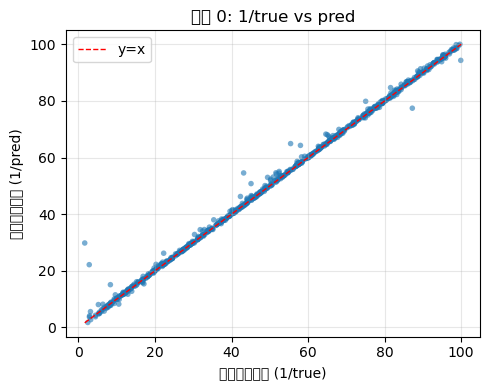

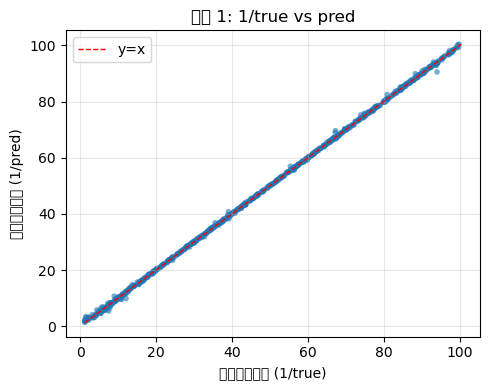

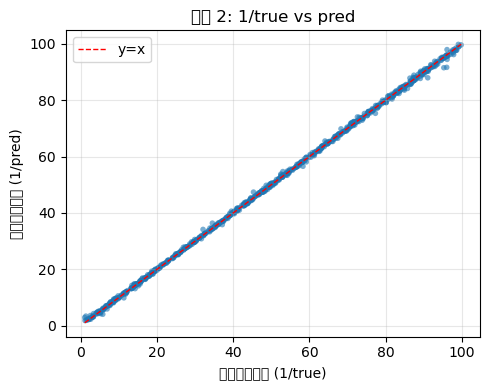

In [ ]:
# Plot scatter charts of inverse predictions vs inverse targets for each dimension
output_dim = preds.shape[1]

for dim in range(output_dim):
    true_vals = targets[:, dim].numpy()
    pred_vals = preds[:, dim].numpy()

    non_zero_mask = true_vals != 0
    if not np.any(non_zero_mask):
        print(f"Dimension {dim}: all target values are 0, so inverse values cannot be computed; skipping plot.")
        continue

    true_inv = 1.0 / true_vals[non_zero_mask]
    pred_inv = 1.0 / pred_vals[non_zero_mask]

    finite_mask = np.isfinite(true_inv) & np.isfinite(pred_inv)
    if not np.any(finite_mask):
        print(f"Dimension {dim}: no valid data available; skipping plot.")
        continue

    true_inv = true_inv[finite_mask]
    pred_filtered = pred_inv[finite_mask]   

    plt.figure(figsize=(5, 4))
    plt.scatter(true_inv, pred_filtered, alpha=0.6, s=16, edgecolors="none")

    min_val = min(true_inv.min(), pred_filtered.min())
    max_val = max(true_inv.max(), pred_filtered.max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.0, label="y=x")

    plt.title(f"Dimension {dim}: 1/true vs 1/pred")
    plt.xlabel("Inverse target (1/true)")
    plt.ylabel("Inverse prediction (1/pred)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
